In [35]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.impute import SimpleImputer


from sklearn.metrics import (
    matthews_corrcoef,
    #balanced_accuracy_score,
    #precision_recall_curve,
    #average_precision_score,
    #roc_curve,
    #roc_auc_score
)


# --- Keit paths
#from google.colab import drive
#drive.mount('/content/drive')
#os.chdir('/content/drive/MyDrive/SB/SB_Project')
# ----------

In [16]:
train_df = pd.read_parquet('classification_ring/data/processed/train.parquet')
val_df = pd.read_parquet('classification_ring/data/processed/val.parquet')

In [ ]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

atchley_features = [
    's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    't_a1', 't_a2', 't_a3', 't_a4', 't_a5'
]
dssp_features = ['s_ss8', 't_ss8']  #categorical
rsa_features = ['s_rsa', 't_rsa']  # numeric
dihedral_features = ['s_phi', 's_psi', 't_phi', 't_psi'] # numeric
di3_features_cat = ['s_3di_letter', 't_3di_letter'] # categorical

# ---------------- Macro categories of features
structural_features = dihedral_features + dssp_features

environment_features = rsa_features + di3_features_cat

all_num = atchley_features + dihedral_features + rsa_features
all_cat = dssp_features + di3_features_cat

print("Feature groups defined:")
print(f"  Atchley: {len(atchley_features)} features")
print(f"  Structural: {len(structural_features)} features")
print(f"  Environment: {len(environment_features)} features")
print(f"  All numeric: {len(all_num)} features")
print(f"  All categorical: {len(all_cat)} features")
print(f"  All: {len(all_num + all_cat)} features")

Feature groups defined:
  Atchley: 10 features
  Structural: 6 features
  Environment: 4 features
  All numeric: 16 features
  All categorical: 4 features
  All: 20 features


Prepare data for training

In [18]:
feature_cols = all_num + all_cat

X_train = train_df[feature_cols].copy()
Y_train = train_df[label_cols].copy()

X_val   = val_df[feature_cols].copy()
Y_val   = val_df[label_cols].copy()

X_train.head()

,s_a1,s_a2,s_a3,s_a4,s_a5,t_a1,t_a2,t_a3,t_a4,t_a5,s_phi,s_psi,t_phi,t_psi,s_rsa,t_rsa,s_ss8,t_ss8,s_3di_letter,t_3di_letter
0,-1.019,-0.987,-1.505,1.266,-0.912,1.831,-0.561,0.533,-0.277,1.648,-0.990,-0.759,-2.920,3.001,0.073,0.259,H,-,P,F
1,-0.591,-1.302,-0.733,1.570,-0.146,0.336,-0.417,-1.673,-1.474,-0.078,-1.132,2.664,-1.720,0.110,0.000,0.000,-,G,A,B
2,-0.384,1.652,1.330,1.045,2.064,1.831,-0.561,0.533,-0.277,1.648,1.342,0.258,-0.944,-0.593,0.357,0.620,T,H,R,R
3,-0.591,-1.302,-0.733,1.570,-0.146,-1.239,-0.547,2.131,0.393,0.816,-1.754,0.040,-1.184,-0.789,0.009,0.006,G,H,B,N
4,-0.384,1.652,1.330,1.045,2.064,0.945,0.828,1.299,-0.169,0.933,-0.955,2.750,1.077,0.955,0.310,0.573,S,-,C,R


In [29]:
def train_and_evaluate(X_train, X_val, Y_train, Y_val, num_cols, cat_cols, subset_name, verbose=True):
    """
    Train a multi-output Random Forest classifier on the given training data and evaluate it on the validation data.
    Use one-hot encoding for categorical features and median imputation for missing values.
    Use only the specified numeric and categorical columns for training and evaluation.
    Pass the name of the subset of features used for training and evaluation as a string to the function, for
    subsequent reporting of results.
    Evaluate on the validation set using MCC

    """
    if verbose:
        print("Training and evaluating on subset:", subset_name, "...")
    # Subselect columns
    X_train_subset = X_train[num_cols + cat_cols].copy()
    X_val_subset = X_val[num_cols + cat_cols].copy()

    #One-hot encode categorical features
    if cat_cols:
        X_train_subset = pd.get_dummies(X_train_subset, columns=cat_cols)
        X_val_subset   = pd.get_dummies(X_val_subset,   columns=cat_cols)
        X_train_subset, X_val_subset = X_train_subset.align(X_val_subset, join='left', axis=1, fill_value=0)
        if verbose:
            print(f"  One-hot encoded {len(cat_cols)} categorical features, resulting in {X_train_subset.shape[1]} total features.")

    imputer = SimpleImputer(strategy='median')
    X_train_subset = pd.DataFrame(imputer.fit_transform(X_train_subset), columns=X_train_subset.columns)
    X_val_subset   = pd.DataFrame(imputer.transform(X_val_subset),       columns=X_val_subset.columns)
    if verbose:
        print(f"  Imputed missing values in {X_train_subset.shape[1]} features using median strategy.")


    rf = MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    )
    rf.fit(X_train_subset, Y_train)
    if verbose:
        print(f"  Trained Random Forest classifier with {len(rf.estimators_)} estimators.")

    y_proba = rf.predict_proba(X_val_subset)
    y_scores = np.column_stack([proba[:, 1] for proba in y_proba])
    
    # ----------------------------------------------------------
    # Evaluate MCC at different thresholds
    # Select best threshold as the one optimizing MCC on validation set
    thresholds = np.linspace(0, 1, 101)

    per_label_best_mccs = []
    per_label_best_thresholds = []

    for label_idx in range(Y_val.shape[1]):
        label_mccs = []
        for threshold in thresholds:
            Y_pred_thr = (y_scores[:, label_idx] >= threshold).astype(int)
            mcc = matthews_corrcoef(Y_val.iloc[:, label_idx], Y_pred_thr)
            label_mccs.append(mcc)
        # compute best threshold for this label
        best_idx = np.argmax(label_mccs)
        best_threshold = thresholds[best_idx]
        per_label_best_thresholds.append(best_threshold)
        per_label_best_mccs.append(label_mccs[best_idx])


    # ----------------------------------------------------

    print(f"\n{'='*50}")
    print(f"Subset: {subset_name}")
    print(f"  Features used: {len(X_train_subset.columns)}")
    print(f"  Per-label MCC @ best threshold: {per_label_best_mccs}")
    print(f"  Per-label best thresholds: {per_label_best_thresholds}")

    return {
        'subset': subset_name,
        'n_features': len(X_train_subset.columns),
        'best_thresholds': per_label_best_thresholds,
        'per_label_mcc@best_threshold': per_label_best_mccs,
        'per_label_mcc@0.5': [
            matthews_corrcoef(Y_val.iloc[:, i], (y_scores >= 0.5).astype(int)[:, i])
            for i in range(Y_val.shape[1])
        ]
    }

print("Helper function defined.")

Helper function defined.


----
Training

In [30]:
results = []

In [31]:
r = train_and_evaluate(X_train, X_val, Y_train, Y_val,
                        num_cols=atchley_features,
                        cat_cols=[],
                        subset_name='Atchley only')
results.append(r)


Training and evaluating on subset: Atchley only ...
  Imputed missing values in 10 features using median strategy.
  Trained Random Forest classifier with 7 estimators.

Subset: Atchley only
  Features used: 10
  Per-label MCC @ best threshold: [0.20932450565997218, 0.10423819217124963, 0.5506036778887913, 0.8527106769984139, 0.45085969548941307, 0.866518118497182, 0.09792213376987692]
  Per-label best thresholds: [np.float64(0.33), np.float64(0.53), np.float64(0.9), np.float64(0.07), np.float64(0.96), np.float64(0.01), np.float64(0.92)]


In [32]:
r = train_and_evaluate(X_train, X_val, Y_train, Y_val,
                        num_cols=dihedral_features,
                        cat_cols=dssp_features,
                        subset_name='Structural only')

results.append(r)

Training and evaluating on subset: Structural only ...
  One-hot encoded 2 categorical features, resulting in 22 total features.
  Imputed missing values in 22 features using median strategy.
  Trained Random Forest classifier with 7 estimators.

Subset: Structural only
  Features used: 22
  Per-label MCC @ best threshold: [0.1165144114481276, 0.07028211853333217, 0.03658367231459354, 0.061158361828847284, 0.025498469912416062, 0.047061050998332375, 0.012431548962574552]
  Per-label best thresholds: [np.float64(0.75), np.float64(0.54), np.float64(0.03), np.float64(0.04), np.float64(0.02), np.float64(0.16), np.float64(0.16)]


In [33]:
r = train_and_evaluate(X_train, X_val, Y_train, Y_val,
                        num_cols=rsa_features,
                        cat_cols=di3_features_cat,
                        subset_name='Environmental only')
results.append(r)

Training and evaluating on subset: Environmental only ...
  One-hot encoded 2 categorical features, resulting in 42 total features.
  Imputed missing values in 42 features using median strategy.
  Trained Random Forest classifier with 7 estimators.

Subset: Environmental only
  Features used: 42
  Per-label MCC @ best threshold: [0.14100863907829608, 0.07432487213435951, 0.07742547728535319, 0.07718719764257939, 0.02904591049427915, 0.03803024347164478, 0.009247953071234516]
  Per-label best thresholds: [np.float64(0.48), np.float64(0.45), np.float64(0.01), np.float64(0.01), np.float64(0.01), np.float64(0.01), np.float64(0.84)]


In [42]:
r = train_and_evaluate(X_train, X_val, Y_train, Y_val,
                        num_cols=all_num,
                        cat_cols=[c for c in all_cat if c not in di3_features_cat],
                        subset_name='All except 3Di')
results.append(r)


Training and evaluating on subset: All except 3Di ...
  One-hot encoded 2 categorical features, resulting in 34 total features.
  Imputed missing values in 34 features using median strategy.
  Trained Random Forest classifier with 7 estimators.

Subset: All except 3Di
  Features used: 34
  Per-label MCC @ best threshold: [0.30172410002545835, 0.151151585216317, 0.5783667221364789, 0.8530902499656159, 0.4676753094409846, 0.8919658407125141, 0.09708587098079835]
  Per-label best thresholds: [np.float64(0.61), np.float64(0.52), np.float64(0.17), np.float64(0.33), np.float64(0.06), np.float64(0.35000000000000003), np.float64(0.51)]


In [54]:
r = train_and_evaluate(X_train, X_val, Y_train, Y_val,
                        num_cols=[n for n in all_num if n not in atchley_features],
                        cat_cols=all_cat,
                        subset_name='All except Atchley')
results.append(r)

Training and evaluating on subset: All except Atchley ...
  One-hot encoded 4 categorical features, resulting in 64 total features.
  Imputed missing values in 64 features using median strategy.
  Trained Random Forest classifier with 7 estimators.

Subset: All except Atchley
  Features used: 64
  Per-label MCC @ best threshold: [0.2852317606821337, 0.17638558367300997, 0.13555610339476454, 0.1249443748556816, 0.0613730675855567, 0.15500423035192168, 0.07270748773845452]
  Per-label best thresholds: [np.float64(0.6900000000000001), np.float64(0.49), np.float64(0.06), np.float64(0.06), np.float64(0.03), np.float64(0.1), np.float64(0.15)]


In [55]:
r = train_and_evaluate(X_train, X_val, Y_train, Y_val,
                        num_cols=all_num,
                        cat_cols=all_cat,
                        subset_name='All features')
results.append(r)

Training and evaluating on subset: All features ...
  One-hot encoded 4 categorical features, resulting in 74 total features.


KeyboardInterrupt: 

Save complete results to avoid re-running

In [59]:
results_df = pd.DataFrame(results)
results_df.to_parquet('classification_ring/results/ablation_results.parquet', index=False)

In [56]:
from pathlib import Path
import numpy as np
import pandas as pd

rows = []

for r in results:
    mcc_best = np.asarray(r['per_label_mcc@best_threshold'], dtype=float)
    mcc_05 = np.asarray(r['per_label_mcc@0.5'], dtype=float)
    thresholds = np.asarray(r['best_thresholds'], dtype=float)

    row = {
        'Subset': r['subset'],
        'N Features': r['n_features'],

        # Store readable list values
        'Per Label MCC @ best threshold': np.round(mcc_best, 4).tolist(),
        'Per Label MCC @ 0.5': np.round(mcc_05, 4).tolist(),

        # Scalar columns for sorting / comparison
        'Mean MCC @ best threshold': round(float(np.mean(mcc_best)), 4),
        'Mean MCC @ 0.5': round(float(np.mean(mcc_05)), 4),
    }

    for i, label in enumerate(label_cols):
        row[f'{label} MCC @ best threshold'] = round(float(mcc_best[i]), 4)
        row[f'{label} threshold'] = round(float(thresholds[i]), 2)
        row[f'{label} MCC @ 0.5'] = round(float(mcc_05[i]), 4)

    rows.append(row)

summary = pd.DataFrame(rows)

summary = summary.sort_values(
    'Mean MCC @ 0.5',
    ascending=False
)

print(summary.to_string(index=False))

out_path = Path('classification_ring/results/rf_feature_ablation.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)

summary.to_csv(out_path, index=False)

summary = summary.sort_values('Per Label MCC @ 0.5', ascending=False)

print(summary.to_string(index=False))

out_path = Path('classification_ring/results/rf_feature_ablation.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)

summary.to_csv(out_path, index=False)

            Subset  N Features                           Per Label MCC @ best threshold                                      Per Label MCC @ 0.5  Mean MCC @ best threshold  Mean MCC @ 0.5  HBOND MCC @ best threshold  HBOND threshold  HBOND MCC @ 0.5  VDW MCC @ best threshold  VDW threshold  VDW MCC @ 0.5  IONIC MCC @ best threshold  IONIC threshold  IONIC MCC @ 0.5  PIPISTACK MCC @ best threshold  PIPISTACK threshold  PIPISTACK MCC @ 0.5  PICATION MCC @ best threshold  PICATION threshold  PICATION MCC @ 0.5  SSBOND MCC @ best threshold  SSBOND threshold  SSBOND MCC @ 0.5  PIHBOND MCC @ best threshold  PIHBOND threshold  PIHBOND MCC @ 0.5
      Atchley only          10 [0.2093, 0.1042, 0.5506, 0.8527, 0.4509, 0.8665, 0.0979]  [0.1975, 0.097, 0.5456, 0.8527, 0.4438, 0.8665, 0.0717]                     0.4475          0.4393                      0.2093             0.33           0.1975                    0.1042           0.53         0.0970                      0.5506             0.90    

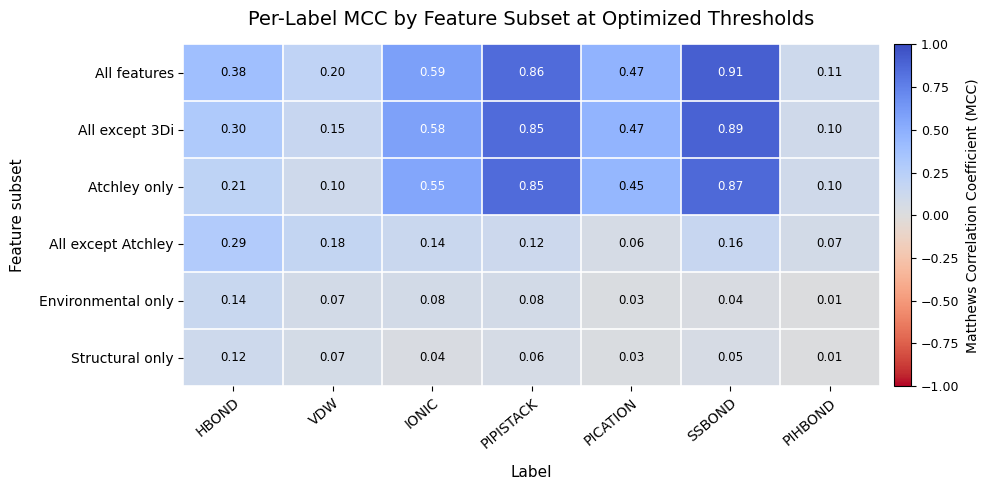

In [57]:
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm

# Build heatmap table
heatmap_data = pd.DataFrame(
    [
        {
            'Subset': r['subset'],
            **{
                label: r['per_label_mcc@best_threshold'][i]
                for i, label in enumerate(label_cols)
            }
        }
        for r in results
    ]
).set_index('Subset')

# Optional: sort rows by mean MCC, best-performing subsets at the top
heatmap_data = heatmap_data.assign(
    Mean_MCC=heatmap_data.mean(axis=1)
).sort_values(
    'Mean_MCC',
    ascending=False
).drop(columns='Mean_MCC')

# Figure size scales with number of rows/columns
fig_width = max(10, 0.75 * len(label_cols) + 3)
fig_height = max(5, 0.45 * len(heatmap_data) + 2)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Center the diverging color scale at 0
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.imshow(
    heatmap_data.values,
    aspect='auto',
    cmap='coolwarm_r',
    norm=norm
)

# Axis labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=40,
    ha='right',
    rotation_mode='anchor',
    fontsize=10
)

ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=10)

# Minor gridlines between cells
ax.set_xticks(np.arange(-0.5, len(heatmap_data.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_data.index), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.2)
ax.tick_params(which='minor', bottom=False, left=False)

# Cell annotations with contrast-aware text color
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]

        text_color = 'white' if abs(value) >= 0.55 else 'black'

        ax.text(
            j,
            i,
            f'{value:.2f}',
            ha='center',
            va='center',
            fontsize=8.5,
            color=text_color
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Matthews Correlation Coefficient (MCC)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Titles and labels
ax.set_title(
    'Per-Label MCC by Feature Subset at Optimized Thresholds',
    fontsize=14,
    pad=14
)

ax.set_xlabel('Label', fontsize=11, labelpad=10)
ax.set_ylabel('Feature subset', fontsize=11, labelpad=10)

# Remove heavy plot border
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# Save outputs
out_dir = Path('report_figures')
out_dir.mkdir(parents=True, exist_ok=True)

png_path = out_dir / 'ablation_mcc_heatmap_report.png'
pdf_path = out_dir / 'ablation_mcc_heatmap_report.pdf'

plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

plt.show()